# Generic PCE Pipeline (Qiskit Method + Problem-to-MaxCut Mapping)

This notebook merges:
1. The Qiskit PCE optimization flow from `pce_qiskit.ipynb` (ansatz + estimator loss + `scipy.minimize`).
2. The generic conversion logic from `knapsack.ipynb` (any `QuadraticProgram` -> QUBO -> weighted MaxCut -> decode back).

You can replace the example problem cell with any `QuadraticProgram` source.


In [1]:
import sys
from pathlib import Path
from itertools import combinations

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as Estimator

from qiskit_optimization.applications import Knapsack
from qiskit_optimization.algorithms import CplexOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_optimization import QuadraticProgram

notebook_dir = Path.cwd()
if not (notebook_dir / "pce").exists():
    candidate = notebook_dir / "quantum-optimization-algorithms" / "PCE"
    if candidate.exists():
        sys.path.append(str(candidate))

from pce import PauliCorrelationEncoding, MaxCutUtility
from qubo_to_maxcut import QUBO


## 1) Define Any Original Problem (`QuadraticProgram`)

Replace this cell with your own problem constructor if needed.


In [2]:
np.random.seed(7)

# Example A (preferred): Knapsack -> QuadraticProgram
# If Docplex/CPLEX is unavailable in your environment, fallback Example B is used.
try:
    num_items = 6
    weights = np.random.randint(1, 10, size=num_items)
    values = np.random.randint(10, 60, size=num_items)
    capacity = int(0.6 * np.sum(weights))

    knapsack = Knapsack(values.tolist(), weights.tolist(), capacity)
    problem = knapsack.to_quadratic_program()

    print("Using knapsack instance")
    print("Weights :", weights)
    print("Values  :", values)
    print("Capacity:", capacity)
except Exception as exc:
    print("Knapsack construction skipped:", exc)
    print("Using fallback unconstrained QuadraticProgram example.")

    problem = QuadraticProgram("fallback_qp")
    for i in range(5):
        problem.binary_var(name=f"x{i}")
    problem.maximize(
        linear={"x0": 2.0, "x1": 1.0, "x2": 3.0, "x3": 2.0, "x4": 1.0},
        quadratic={
            ("x0", "x1"): -2.0,
            ("x0", "x2"): 1.0,
            ("x1", "x3"): -1.0,
            ("x2", "x4"): -2.0,
            ("x3", "x4"): 1.5,
        },
    )

print(problem.prettyprint())


Using knapsack instance
Weights : [5 7 4 4 8 8]
Values  : [38 24 33 18 35 56]
Capacity: 21
Problem name: Knapsack

Maximize
  38*x_0 + 24*x_1 + 33*x_2 + 18*x_3 + 35*x_4 + 56*x_5

Subject to
  Linear constraints (1)
    5*x_0 + 7*x_1 + 4*x_2 + 4*x_3 + 8*x_4 + 8*x_5 <= 21  'c0'

  Binary variables (6)
    x_0 x_1 x_2 x_3 x_4 x_5



Optional baseline from the original problem domain (exact solver).


In [3]:
try:
    baseline = CplexOptimizer().solve(problem)
    print("Exact objective:", baseline.fval)
    print("Exact bitstring:", baseline.x)
except Exception as exc:
    print("Cplex baseline skipped:", exc)


Exact objective: 145.0
Exact bitstring: [1. 0. 1. 1. 0. 1.]


## 2) Convert Original Problem -> QUBO -> Weighted MaxCut


In [5]:
converter = QuadraticProgramToQubo()
qubo = converter.convert(problem)

linear = qubo.objective.linear.to_array()
quadratic = qubo.objective.quadratic.to_array()

qubo_to_mc = QUBO(quadratic, linear)
qubo_to_mc.linear_to_square()
max_cut_weight_matrix = qubo_to_mc.to_maxcut()

def create_weighted_nx_graph(weight_matrix):
    graph = nx.Graph()
    n = len(weight_matrix)
    graph.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + 1, n):
            w = float(weight_matrix[i, j])
            if abs(w) > 1e-12:
                graph.add_edge(i, j, weight=w)
    return graph

maxcut_nx_graph = create_weighted_nx_graph(max_cut_weight_matrix)
print("QUBO vars:", qubo.get_num_binary_vars())
print("Weighted MaxCut nodes (includes anchor node 0):", maxcut_nx_graph.number_of_nodes())
print("Weighted MaxCut edges:", maxcut_nx_graph.number_of_edges())


QUBO vars: 11
Weighted MaxCut nodes (includes anchor node 0): 12
Weighted MaxCut edges: 66


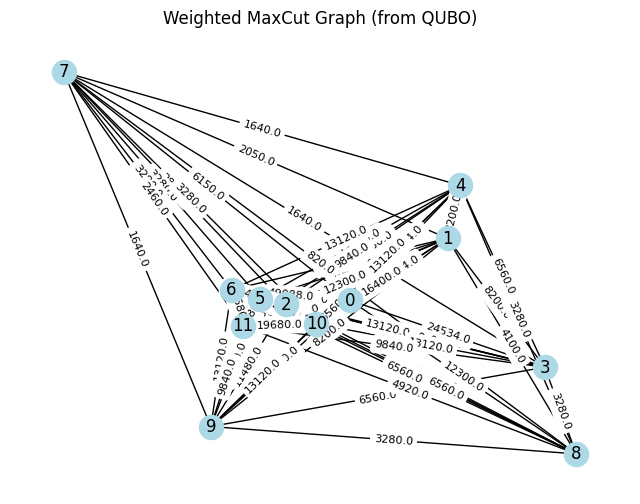

In [6]:
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(maxcut_nx_graph, seed=11)
nx.draw_networkx(maxcut_nx_graph, pos=pos, node_color="lightblue", with_labels=True)
edge_labels = nx.get_edge_attributes(maxcut_nx_graph, "weight")
nx.draw_networkx_edge_labels(maxcut_nx_graph, pos=pos, edge_labels=edge_labels, font_size=8)
plt.title("Weighted MaxCut Graph (from QUBO)")
plt.axis("off")
plt.show()


## 3) Choose `k`, compute required qubits, and generate Pauli strings

This is the explicit compression cell you requested:
- Set `k`.
- Compute minimal qubit count.
- List Pauli strings used for encoding.


In [7]:
pauli_encoder = PauliCorrelationEncoding()

# User choice
k = 2

num_nodes = maxcut_nx_graph.number_of_nodes()
num_qubits = pauli_encoder.find_n(num_nodes, k)

# Strings in the same X/Y/Z block order used by the Qiskit PCE notebook
pauli_strings = pauli_encoder.generate_pauli_strings(num_qubits, num_nodes, k)

# Split by operator family to preserve the pce_qiskit methodology
pauli_strings_x = []
pauli_strings_y = []
pauli_strings_z = []
for label in pauli_strings:
    if "X" in label:
        pauli_strings_x.append(label[::-1])
    elif "Y" in label:
        pauli_strings_y.append(label[::-1])
    else:
        pauli_strings_z.append(label[::-1])

print(f"k = {k}")
print(f"Number of encoded nodes = {num_nodes}")
print(f"Required qubits (minimum) = {num_qubits}")
print(f"Pauli strings used = {len(pauli_strings)}")
print("First 12 Pauli strings:", pauli_strings[:12])

pauli_encoding_x = [SparsePauliOp.from_list([(p, 1.0)]) for p in pauli_strings_x]
pauli_encoding_y = [SparsePauliOp.from_list([(p, 1.0)]) for p in pauli_strings_y]
pauli_encoding_z = [SparsePauliOp.from_list([(p, 1.0)]) for p in pauli_strings_z]


k = 2
Number of encoded nodes = 12
Required qubits (minimum) = 4
Pauli strings used = 12
First 12 Pauli strings: ['XXII', 'XIXI', 'XIIX', 'IXXI', 'IXIX', 'IIXX', 'YYII', 'YIYI', 'YIIY', 'IYYI', 'IYIY', 'IIYY']


## 4) Qiskit-style PCE optimization (kept from `pce_qiskit.ipynb`)


In [8]:
backend = AerSimulator(method="matrix_product_state")
estimator = Estimator()

# Same style ansatz as pce_qiskit
qc = efficient_su2(num_qubits, ["ry", "rz"], reps=2)
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
qc = pm.run(qc)

# Apply transpilation layout to observables (same pattern as pce_qiskit)
pce_hamiltonian = [
    [op.apply_layout(qc.layout) for op in pauli_encoding_x],
    [op.apply_layout(qc.layout) for op in pauli_encoding_y],
    [op.apply_layout(qc.layout) for op in pauli_encoding_z],
]

alpha = num_qubits
beta = 0.5
nu = pauli_encoder.calculate_nu(maxcut_nx_graph)

experiment_result = []

def loss_func_estimator(x, ansatz, hamiltonian, estimator, graph):
    pubs = []
    for block in hamiltonian:
        if len(block) > 0:
            pubs.append((ansatz, block, x))

    result = estimator.run(pubs).result()

    # Preserve node order X-block -> Y-block -> Z-block
    node_exp_map = {}
    idx = 0
    for r in result:
        for ev in np.atleast_1d(r.data.evs):
            node_exp_map[idx] = float(np.real(ev))
            idx += 1

    # Weighted MaxCut-style edge term
    edge_loss = 0.0
    for u, v, data in graph.edges(data=True):
        w = float(data["weight"])
        edge_loss += w * np.tanh(alpha * node_exp_map[u]) * np.tanh(alpha * node_exp_map[v])

    # Same regularization style as the Qiskit notebook
    reg = 0.0
    for i in range(graph.number_of_nodes()):
        reg += np.tanh(alpha * node_exp_map[i]) ** 2
    reg = (reg / graph.number_of_nodes()) ** 2
    reg = beta * nu * reg

    total = edge_loss + reg
    experiment_result.append({"loss": total, "exp_map": node_exp_map})
    print(f"Iter {len(experiment_result)-1}: {total:.8f}")
    return total

np.random.seed(42)
initial_params = np.random.rand(qc.num_parameters)
maxiter = 60

result = minimize(
    lambda x: loss_func_estimator(x, qc, pce_hamiltonian, estimator, maxcut_nx_graph),
    initial_params,
    method="COBYLA",
    options={"maxiter": maxiter},
)
print(result)


Iter 0: 154162.95671226
Iter 1: 21407.39288537
Iter 2: 10830.63995295
Iter 3: 10244.53950092
Iter 4: 14496.72633455
Iter 5: 128750.11762540
Iter 6: -7960.06994399
Iter 7: -993.81080956
Iter 8: -3888.73900698
Iter 9: -7633.94996692
Iter 10: -3901.87844221
Iter 11: 3365.94274184
Iter 12: 61282.51015041
Iter 13: 35995.83779293
Iter 14: -17359.97852154
Iter 15: 27689.37296981
Iter 16: 18181.51932861
Iter 17: -29004.90439335
Iter 18: 24798.38343126
Iter 19: -24603.88946596
Iter 20: -28705.95998464
Iter 21: -1753.10396948
Iter 22: 114373.37425622
Iter 23: -25350.10389552
Iter 24: 8377.79646709
Iter 25: -35448.44113336
Iter 26: -28157.24321041
Iter 27: -22264.53867386
Iter 28: 19168.23639832
Iter 29: -34942.15513135
Iter 30: -20563.27000956
Iter 31: -74.55117569
Iter 32: -34952.86819732
Iter 33: -39408.09477749
Iter 34: -5307.38182201
Iter 35: -42138.60164371
Iter 36: -30144.24483615
Iter 37: -38411.41896872
Iter 38: -32905.31364910
Iter 39: -37083.65932497
Iter 40: -42554.23265121
Iter 41: -

## 5) Decode back: MaxCut solution -> QUBO solution -> original problem solution


In [9]:
max_cut_utility = MaxCutUtility(max_cut_weight_matrix)

final_exp = experiment_result[-1]["exp_map"]
maxcut_solution = [1 if final_exp[i] >= 0 else 0 for i in range(num_nodes)]

weighted_cut_value = max_cut_utility.evaluate_max_cut(maxcut_solution, max_cut_weight_matrix)
qubo_solution = max_cut_utility.max_cut_to_qubo_solution(maxcut_solution)
qubo_cost = qubo.objective.evaluate(np.array(qubo_solution, dtype=int))

original_solution = converter.interpret(qubo_solution)
original_objective = problem.objective.evaluate(original_solution)
original_feasible = problem.get_feasibility_info(original_solution)[0]

print("PCE MaxCut bitstring            :", maxcut_solution)
print("PCE weighted cut value          :", weighted_cut_value)
print("Decoded QUBO bitstring          :", qubo_solution)
print("Decoded QUBO objective          :", qubo_cost)
print("Decoded original objective      :", original_objective)
print("Decoded original feasible       :", original_feasible)
print("Decoded original variable array :", original_solution)


PCE MaxCut bitstring            : [0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1]
PCE weighted cut value          : 531054.0
Decoded QUBO bitstring          : [0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0]
Decoded QUBO objective          : -51.0
Decoded original objective      : 51.0
Decoded original feasible       : True
Decoded original variable array : [0. 0. 1. 1. 0. 0.]


Optional local search on top of decoded QUBO bits (same utility used in your `knapsack.ipynb`).


In [10]:
improved_qubo_bits, improved_qubo_cost = max_cut_utility.bit_swap_search(
    qubo, bitstring=qubo_solution.copy()
)

improved_original_solution = converter.interpret(improved_qubo_bits)
improved_original_objective = problem.objective.evaluate(improved_original_solution)
improved_original_feasible = problem.get_feasibility_info(improved_original_solution)[0]

print("Improved QUBO bitstring         :", improved_qubo_bits)
print("Improved QUBO objective         :", improved_qubo_cost)
print("Improved original objective     :", improved_original_objective)
print("Improved original feasible      :", improved_original_feasible)
print("Improved original variable array:", improved_original_solution)


Starting cost: -51.0
Multi-bit flip: Improved solution by flipping bits (4, 9): Cost = -86.0
Multi-bit flip: Improved solution by flipping bits (0, 2, 6): Cost = -91.0
Multi-bit flip: Improved solution by flipping bits (3, 5, 8): Cost = -129.0
Final best cost: -129.0
Improved QUBO bitstring         : [1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0]
Improved QUBO objective         : -129.0
Improved original objective     : 129.0
Improved original feasible      : True
Improved original variable array: [1. 0. 0. 0. 1. 1.]
